# Batch
- 为什么要引入批量
  - 如果每次只处理一个样本，并行度低，无法完全利用 GPU
  - 单个样本无法代表所有训练数据，导致梯度更新不稳定
- 批量大小
  - 使用全部训练数据作为批量大小
  - 使用小批量（mini batch），如 16、32、64，在训练集上多次迭代
- Batch size 是超参数

Pytorch 中的 Dataset 和 DataLoader
- Dataset 用于定义数据集
- DataLoader 通过迭代从数据集中加载数据（需要将 Dataset 传入 DataLoader）

Epoch [1/20], Loss: 0.8303
Epoch [2/20], Loss: 0.5151
Epoch [3/20], Loss: 0.5512
Epoch [4/20], Loss: 0.4317
Epoch [5/20], Loss: 0.3944
Epoch [6/20], Loss: 0.3668
Epoch [7/20], Loss: 0.3104
Epoch [8/20], Loss: 0.2947
Epoch [9/20], Loss: 0.2648
Epoch [10/20], Loss: 0.2486
Epoch [11/20], Loss: 0.2363
Epoch [12/20], Loss: 0.2244
Epoch [13/20], Loss: 0.2124
Epoch [14/20], Loss: 0.2002
Epoch [15/20], Loss: 0.1932
Epoch [16/20], Loss: 0.1818
Epoch [17/20], Loss: 0.1720
Epoch [18/20], Loss: 0.1687
Epoch [19/20], Loss: 0.1632
Epoch [20/20], Loss: 0.1581


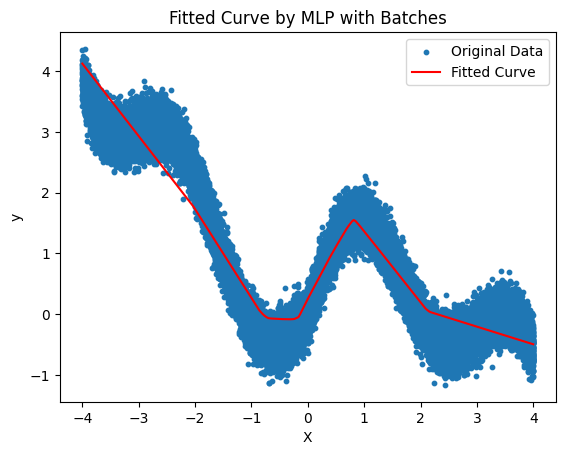

In [7]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt

# ===================== 1. 构建人工数据集 =====================
# 自定义数据集类
class NonlinearDataset(Dataset):
    def __init__(self, num_samples=5000):
        super(NonlinearDataset, self).__init__()
        
        # 生成数据
        self.X = torch.linspace(-4, 4, num_samples).unsqueeze(1)  # (num_samples, 1)
        self.y = (
            torch.sin(2 * self.X)
            + torch.log(torch.abs(self.X) + 1)
            - 0.05 * self.X**3
            + torch.randn(num_samples, 1) * 0.2
        )  # (num_samples, 1)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

# 实例化数据集
dataset = NonlinearDataset(num_samples=50000)

# 创建 DataLoader，指定批量大小和是否打乱数据
batch_size = 10000
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

# ===================== 2. 定义 MLP 模型 =====================
class MLPModel(nn.Module):
    def __init__(self):
        super(MLPModel, self).__init__()
        
        # 多层感知机，包含两层隐藏层
        self.mlp = nn.Sequential(
            nn.Linear(1, 64),  # 输入维度为1，隐藏层维度为64
            nn.ReLU(),         # 激活函数 ReLU
            nn.Linear(64, 64), # 隐藏层维度为64
            nn.ReLU(),         # 激活函数 ReLU
            nn.Linear(64, 1),  # 输出维度为1
        )

    def forward(self, x):
        return self.mlp(x)

# 实例化模型
model = MLPModel()

# ===================== 3. 定义损失函数和优化器 =====================
# 均方误差作为损失函数
criterion = nn.MSELoss()

# Adam 作为优化器
optimizer = optim.Adam(model.parameters(), lr=0.01)  # 学习率 0.01

# ===================== 4. 训练模型 =====================
epochs = 20  # 训练回合数
for epoch in range(epochs):
    for X_batch, y_batch in dataloader:
        # 使用模型预测输出
        predictions = model(X_batch)
        
        # 计算损失
        loss = criterion(predictions, y_batch)
        
        # 梯度清零，防止累积
        optimizer.zero_grad()
        
        # 计算梯度
        loss.backward()
        
        # 更新参数
        optimizer.step()

    # 打印训练过程中的损失值
    print(f'Epoch [{epoch + 1}/{epochs}], Loss: {loss.item():.4f}')

# ===================== 5. 可视化结果 =====================
# 使用训练好的模型预测
with torch.no_grad():
    predictions = model(dataset.X)

# 原始数据
plt.scatter(dataset.X.numpy(), dataset.y.numpy(), label='Original Data', s=10)

# 预测数据
plt.plot(dataset.X.numpy(), predictions.numpy(), color='red', label='Fitted Curve')

plt.xlabel('X')
plt.ylabel('y')
plt.legend()
plt.title("Fitted Curve by MLP with Batches")
plt.show()
